🟢 Ускорение MPS (Metal) активировано.
Загружены данные из файла data/historical/AMZN.csv
Данные подготовлены. Всего точек: 2515
Генерация окон и вейвлет-процессинг...
Размер Train X: (2224, 20, 5)
Размер Test X: (231, 20, 5)
Начало обучения...
Epoch 5/100, Loss: 1.006475
Epoch 10/100, Loss: 1.005333
Epoch 15/100, Loss: 1.011675
Epoch 20/100, Loss: 0.970233
Epoch 25/100, Loss: 0.948682
Epoch 30/100, Loss: 0.897852
Epoch 35/100, Loss: 0.838965
Epoch 40/100, Loss: 0.764714
Epoch 45/100, Loss: 0.693255
Epoch 50/100, Loss: 0.615372
Epoch 55/100, Loss: 0.557635
Epoch 60/100, Loss: 0.502412
Epoch 65/100, Loss: 0.461189
Epoch 70/100, Loss: 0.416030
Epoch 75/100, Loss: 0.381202
Epoch 80/100, Loss: 0.335050
Epoch 85/100, Loss: 0.292116
Epoch 90/100, Loss: 0.273824
Epoch 95/100, Loss: 0.224036
Epoch 100/100, Loss: 0.212394
------------------------------
📊 RESULTS FOR AMZN
RMSE: 0.020322
MAE:  0.015665
Directional Accuracy (DA): 53.25%
Confusion Matrix (Up vs Down):
[[78 44]
 [64 45]]


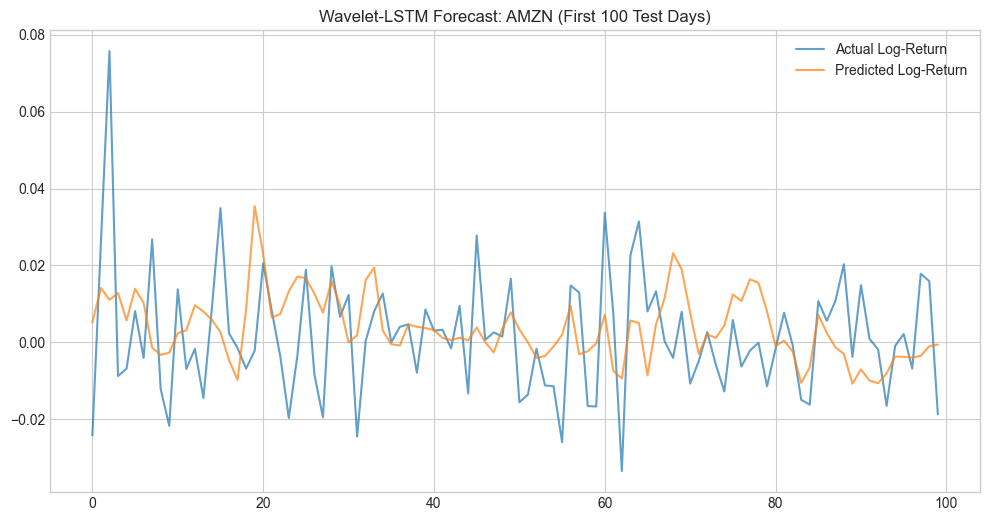

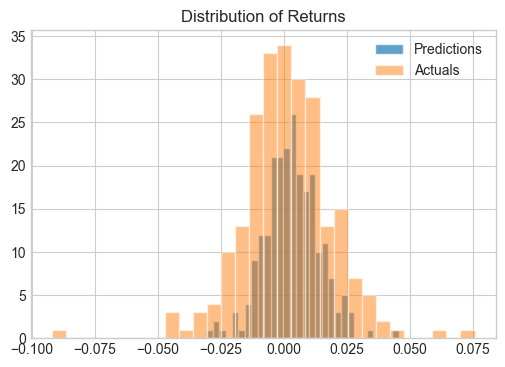

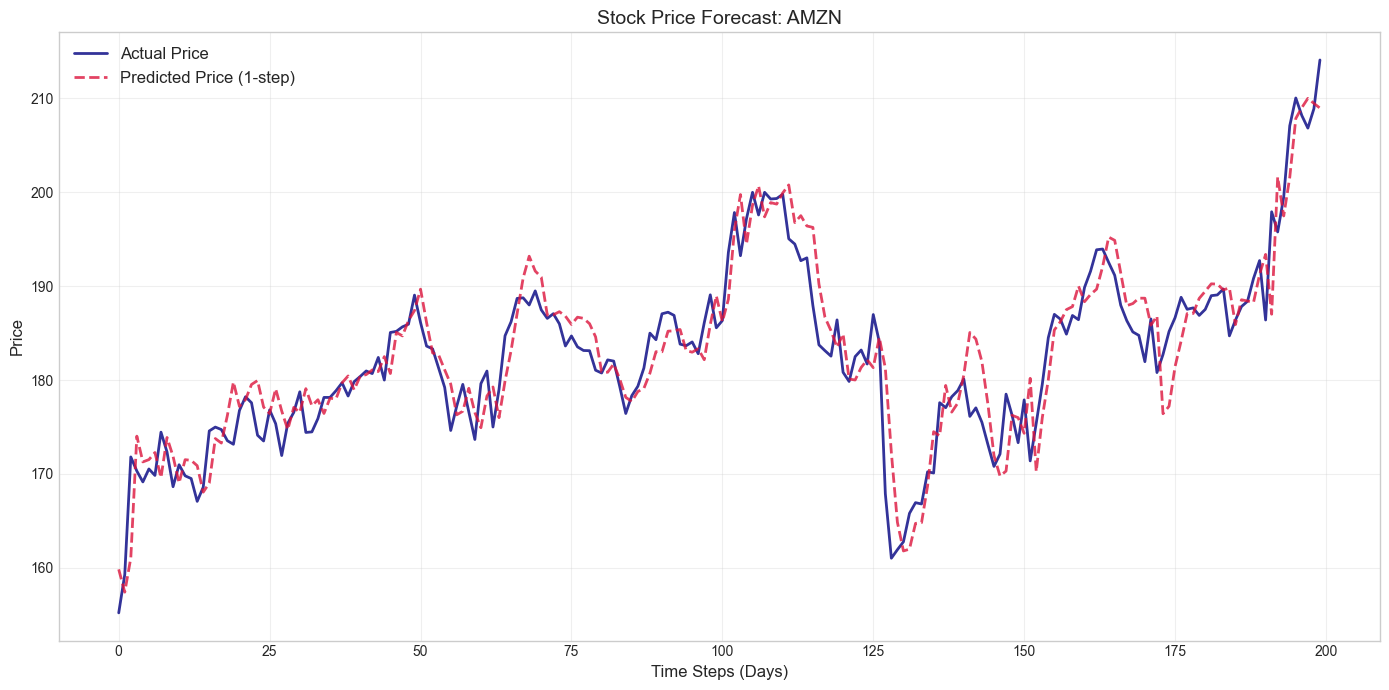

Price chart generated and saved.

💰 FINANCIAL PERFORMANCE: AMZN
Metric               | Buy & Hold      | Wavelet-LSTM   
-------------------------------------------------------
Total Return         |        39.18% |        73.70%
Sharpe Ratio         |       1.2582   |       2.1133
Max Drawdown         | --              |       -13.42%


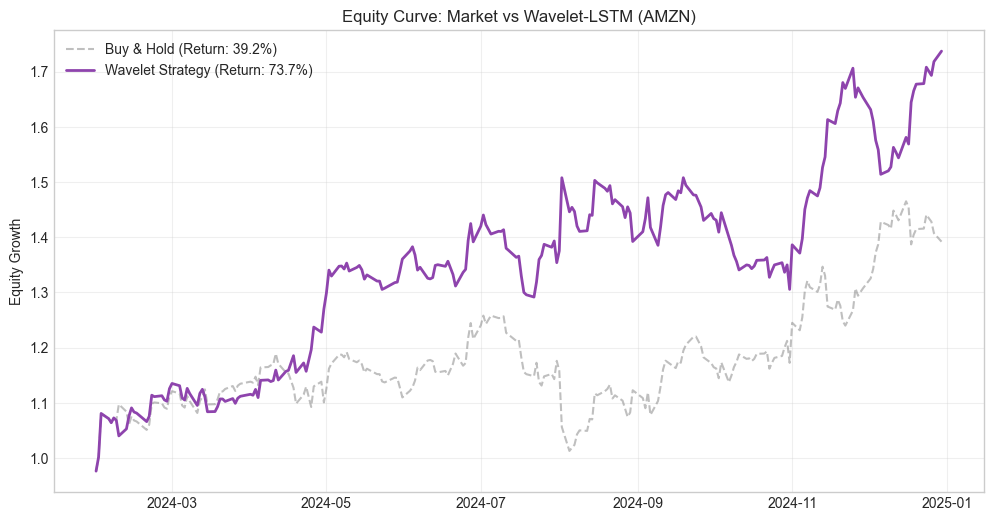

In [45]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import pywt
import warnings
import os
# --- SYSTEM CONFIG ---
warnings.filterwarnings('ignore')


if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("🟢 Ускорение MPS (Metal) активировано.")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("🟢 Ускорение CUDA активировано.")
else:
    DEVICE = torch.device("cpu")
    print("🔴 Используется CPU.")

# --- CONFIG ---
TICKER = 'AMZN' # Тикер (для примера, данные будут фиктивные)
#
DATA_PATH = f'data/historical/{TICKER}.csv'

if os.path.exists(DATA_PATH):
    try:
        df = pd.read_csv(DATA_PATH)
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        print(f"Загружены данные из файла {DATA_PATH}")
    except Exception as e:
        print(f"Ошибка при загрузке данных из файла: {e}")

else:
    print(f"Файл {DATA_PATH} не найден")



# Параметры модели
LOOKBACK = 20       # Длина окна (в днях)
PREDICT_STEP = 1    # Прогноз на 1 день
# Подберите дату разделения в зависимости от ваших данных
TRAIN_SPLIT_DATE = '2024-01-01'
BATCH_SIZE = 64
EPOCHS = 100
LR = 0.0005

print(f"Данные подготовлены. Всего точек: {len(df)}")

# --- 1. FEATURE ENGINEERING ---
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def create_features(df):
    data = df.copy()

    # 1. Log-Return (Целевая переменная и фича)
    # r_t = ln(P_t / P_{t-1})
    data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))

    # 2. Volatility (Rolling Std Dev of returns)
    data['Volatility'] = data['Log_Ret'].rolling(window=20).std()

    # 3. Technical Indicators
    data['RSI'] = calculate_rsi(data['Close'])
    data['MA_20'] = data['Close'].rolling(window=20).mean()

    # Дистанция от MA (нормализованная)
    data['Dist_MA'] = (data['Close'] - data['MA_20']) / data['MA_20']

    # Удаляем NaN, появившиеся из-за лагов
    data.dropna(inplace=True)
    return data

df_features = create_features(df)

# --- 2. DATA PREPARATION (Strict No-Leakage) ---

# Разделение на Train и Test ДО масштабирования
train_data = df_features[df_features.index < TRAIN_SPLIT_DATE]
test_data = df_features[df_features.index >= TRAIN_SPLIT_DATE]

# Определяем фичи для входа (исключая дату и сырые цены, оставляем стационарные)
feature_cols = ['Log_Ret', 'Volatility', 'RSI', 'Dist_MA']
target_col = 'Log_Ret'

# Scaling (Fit только на Train!)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data[feature_cols])
test_scaled = scaler.transform(test_data[feature_cols])

# Конвертация обратно в DataFrame для удобства нарезки окон
train_df_scaled = pd.DataFrame(train_scaled, columns=feature_cols, index=train_data.index)
test_df_scaled = pd.DataFrame(test_scaled, columns=feature_cols, index=test_data.index)


# --- 3. WAVELET HELPER & DATASET ---
def apply_wavelet_smooth(window_data, wavelet='db4', level=1):
    coeffs = pywt.wavedec(window_data, wavelet, mode='periodization', level=level)
    coeffs_rec = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    rec_signal = pywt.waverec(coeffs_rec, wavelet, mode='periodization')
    if len(rec_signal) > len(window_data):
        rec_signal = rec_signal[:len(window_data)]
    elif len(rec_signal) < len(window_data):
        rec_signal = np.pad(rec_signal, (0, len(window_data)-len(rec_signal)), 'edge')
    return rec_signal

def create_sequences(data_df, target_values, lookback):
    X, y = [], []
    values = data_df.values
    targets = target_values.values
    for i in range(len(values) - lookback):
        window = values[i : i + lookback]
        log_ret_window = window[:, 0]
        trend_component = apply_wavelet_smooth(log_ret_window)
        trend_component = trend_component.reshape(-1, 1)
        window_with_wavelet = np.hstack((window, trend_component))
        X.append(window_with_wavelet)
        y.append(targets[i + lookback])
    return np.array(X), np.array(y)

print("Генерация окон и вейвлет-процессинг...")
X_train, y_train = create_sequences(train_df_scaled, train_df_scaled[target_col], LOOKBACK)
X_test, y_test = create_sequences(test_df_scaled, test_df_scaled[target_col], LOOKBACK)

X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

print(f"Размер Train X: {X_train.shape}")
print(f"Размер Test X: {X_test.shape}")

# --- 4. MODEL ARCHITECTURE ---
class WaveletLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1, dropout=0.2):
        super(WaveletLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.activation = nn.Identity()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(DEVICE)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        return out

INPUT_DIM = X_train.shape[2]
HIDDEN_DIM = 128
LAYERS = 2

model = WaveletLSTM(INPUT_DIM, HIDDEN_DIM, LAYERS).to(DEVICE)
criterion = nn.MSELoss() # Можно попробовать nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# --- 5. TRAINING LOOP ---
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
loss_history = []

print("Начало обучения...")
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.6f}")

# --- 6. EVALUATION ---
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).cpu().numpy()
    actuals = y_test_t.cpu().numpy()

dummy_pred = np.zeros((len(predictions), len(feature_cols)))
dummy_act = np.zeros((len(actuals), len(feature_cols)))

dummy_pred[:, 0] = predictions.flatten()
dummy_act[:, 0] = actuals.flatten()

pred_rescaled = scaler.inverse_transform(dummy_pred)[:, 0]
act_rescaled = scaler.inverse_transform(dummy_act)[:, 0]

rmse = np.sqrt(mean_squared_error(act_rescaled, pred_rescaled))
mae = mean_absolute_error(act_rescaled, pred_rescaled)

pred_sign = np.sign(pred_rescaled)
act_sign = np.sign(act_rescaled)
da = accuracy_score(act_sign, pred_sign)

print("-" * 30)
print(f"📊 RESULTS FOR {TICKER}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"Directional Accuracy (DA): {da*100:.2f}%")

cm = confusion_matrix(act_sign, pred_sign, labels=[1, -1])
print("Confusion Matrix (Up vs Down):")
print(cm)

# --- 7. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(act_rescaled[:100], label='Actual Log-Return', alpha=0.7)
plt.plot(pred_rescaled[:100], label='Predicted Log-Return', alpha=0.7)
plt.title(f'Wavelet-LSTM Forecast: {TICKER} (First 100 Test Days)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(pred_rescaled, bins=30, alpha=0.7, label='Predictions')
plt.hist(act_rescaled, bins=30, alpha=0.5, label='Actuals')
plt.title('Distribution of Returns')
plt.legend()
plt.show()

# --- 8. PRICE RECONSTRUCTION & PLOTTING ---
# Get actual Close prices from the test set
# test_data.index corresponds to dates in the test set
test_close_prices = df['Close'][test_data.index].values

# We need to align prices with predictions.
# The model predicts for time 't' using window ending at 't-1'.
# The first prediction corresponds to index = LOOKBACK in the test set.
actual_prices = test_close_prices[LOOKBACK:]
prev_prices = test_close_prices[LOOKBACK-1 : -1]  # Prices at t-1

# Reconstruct predicted prices: Price_t = Price_{t-1} * exp(Log_Return_t)
pred_prices = prev_prices * np.exp(pred_rescaled)

# Visualization of Price
plt.figure(figsize=(14, 7))

# Plot a subset (e.g., first 200 points) for better visibility, or remove [:200] for full range
plot_limit = 200

plt.plot(actual_prices[:plot_limit], label='Actual Price', color='navy', alpha=0.8, linewidth=2)
plt.plot(pred_prices[:plot_limit], label='Predicted Price (1-step)', color='crimson', alpha=0.8, linestyle='--', linewidth=2)

plt.title(f'Stock Price Forecast: {TICKER}', fontsize=14)
plt.xlabel('Time Steps (Days)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{TICKER}_price_chart.png')
plt.show()

print("Price chart generated and saved.")

# ==========================================
# 9. FINANCIAL BACKTEST (Add this to match Thesis 3.3.3)
# ==========================================

# 1. Prepare Data for Backtest
# Align dates: test_data index starting from LOOKBACK
backtest_dates = test_data.index[LOOKBACK:]

# Create DataFrame
df_backtest = pd.DataFrame(index=backtest_dates)
df_backtest['Actual_Log_Ret'] = act_rescaled
df_backtest['Pred_Log_Ret'] = pred_rescaled

# 2. Strategy Logic
# Signal: 1 (Long) if Pred > 0, else -1 (Short)
df_backtest['Signal'] = np.sign(df_backtest['Pred_Log_Ret'])

# Strategy Returns: Signal * Actual Return
df_backtest['Strategy_Log_Ret'] = df_backtest['Signal'] * df_backtest['Actual_Log_Ret']

# 3. Cumulative Returns
df_backtest['Cum_BH'] = np.exp(df_backtest['Actual_Log_Ret'].cumsum())
df_backtest['Cum_Strategy'] = np.exp(df_backtest['Strategy_Log_Ret'].cumsum())

# ==========================================
# 10. METRICS CALCULATION
# ==========================================
def calculate_metrics(returns_series):
    annual_factor = 252
    total_ret = np.exp(np.sum(returns_series)) - 1
    annual_ret = np.mean(returns_series) * annual_factor
    volatility = np.std(returns_series) * np.sqrt(annual_factor)
    sharpe = annual_ret / volatility if volatility != 0 else 0
    return total_ret, sharpe, volatility

# Metrics
bh_total, bh_sharpe, bh_vol = calculate_metrics(df_backtest['Actual_Log_Ret'])
strat_total, strat_sharpe, strat_vol = calculate_metrics(df_backtest['Strategy_Log_Ret'])

# Max Drawdown
cum_ret = df_backtest['Cum_Strategy']
running_max = cum_ret.cummax()
drawdown = (cum_ret - running_max) / running_max
max_drawdown = drawdown.min()

print("\n" + "="*40)
print(f"💰 FINANCIAL PERFORMANCE: {TICKER}")
print("="*40)
print(f"{'Metric':<20} | {'Buy & Hold':<15} | {'Wavelet-LSTM':<15}")
print("-" * 55)
print(f"{'Total Return':<20} | {bh_total*100:12.2f}% | {strat_total*100:12.2f}%")
print(f"{'Sharpe Ratio':<20} | {bh_sharpe:12.4f}   | {strat_sharpe:12.4f}")
print(f"{'Max Drawdown':<20} | {'--':<12}    | {max_drawdown*100:12.2f}%")
print("="*40)

# ==========================================
# 11. EQUITY CURVE PLOT
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(df_backtest.index, df_backtest['Cum_BH'],
         label=f'Buy & Hold (Return: {bh_total*100:.1f}%)', color='gray', alpha=0.5, linestyle='--')
plt.plot(df_backtest.index, df_backtest['Cum_Strategy'],
         label=f'Wavelet Strategy (Return: {strat_total*100:.1f}%)', color='#8e44ad', linewidth=2)
plt.title(f'Equity Curve: Market vs Wavelet-LSTM ({TICKER})')
plt.ylabel('Equity Growth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{TICKER}_equity_curve.png')
plt.show()

## Сверху WAVELET+LSTM

# ARIMA+LSTM

✅ Device: mps
📈 Training ARIMA Backbone...
🧠 Training LSTM...
Epoch 20/100 | Loss: 0.976314
Epoch 40/100 | Loss: 0.950233
Epoch 60/100 | Loss: 0.771989
Epoch 80/100 | Loss: 0.509608
Epoch 100/100 | Loss: 0.423132

🏆 FINAL METRICS: AMZN
RMSE (Log Returns): 0.020555
R² Score:           -0.295779
Direction Accuracy: 50.22%


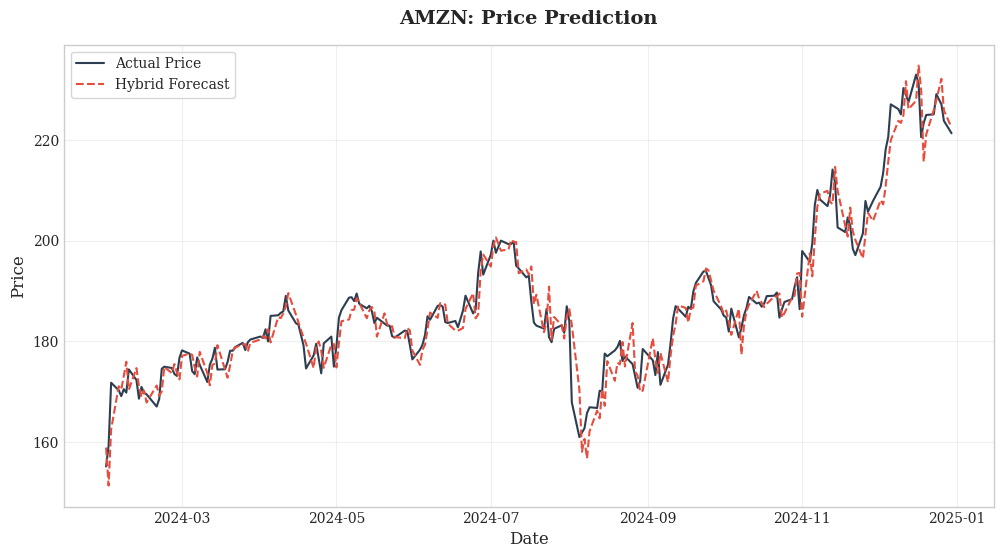

💾 Saved: results_fixed_lr/01_price_forecast.png


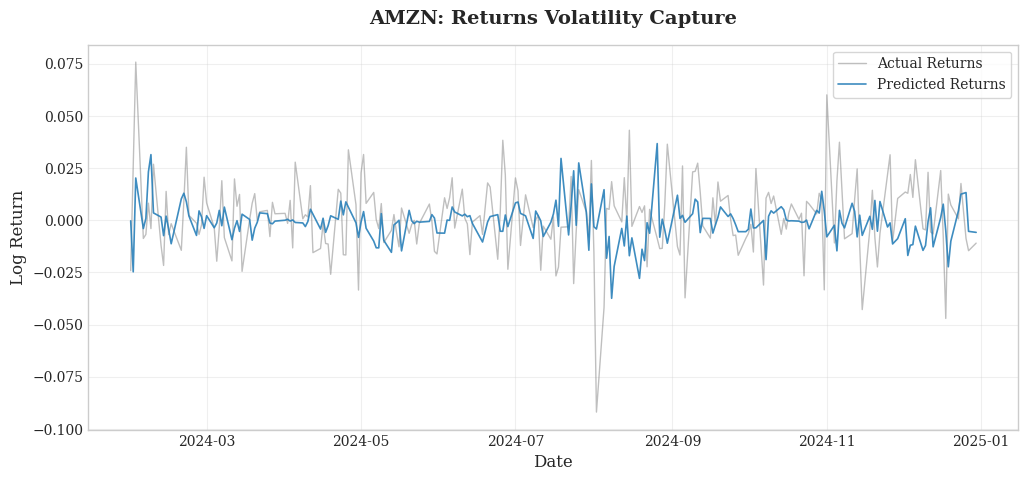

💾 Saved: results_fixed_lr/02_returns_volatility.png


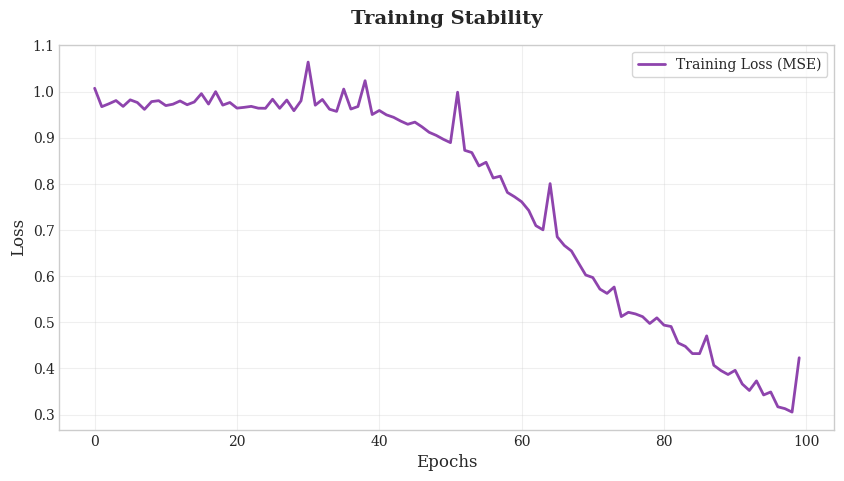

💾 Saved: results_fixed_lr/03_loss_curve.png


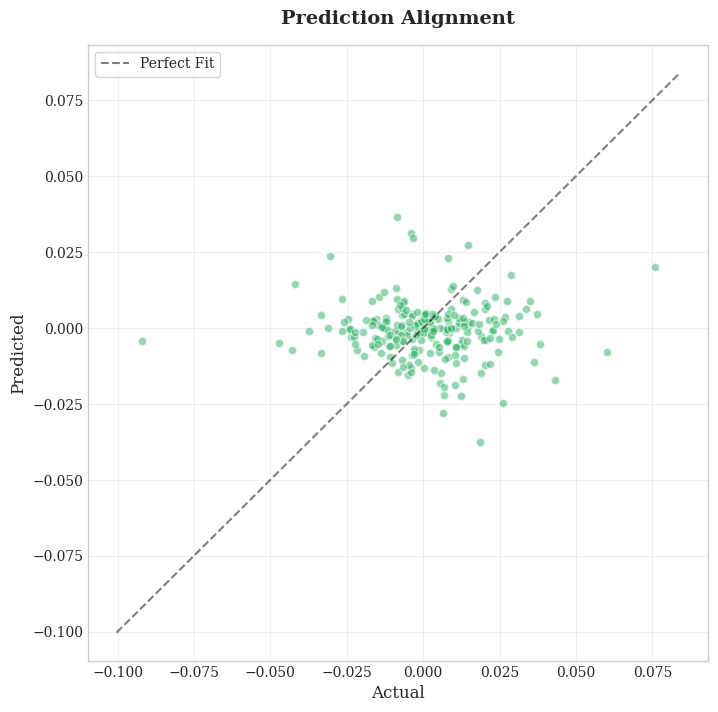

💾 Saved: results_fixed_lr/04_scatter_fit.png


In [76]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, r2_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random

# ==========================================
# 🛠 SETUP & SEEDING
# ==========================================
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'

# Фиксируем Seed для воспроизводимости
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ==========================================
# ⚙️ SETTINGS
# ==========================================
TICKER = 'AMZN'
DATA_PATH = f'data/historical/{TICKER}.csv'
OUTPUT_DIR = 'results_fixed_lr'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_SPLIT_DATE = '2024-01-01'
LOOKBACK = 20
ARIMA_ORDER = (5, 0, 1)

# LSTM Hyperparams
LSTM_HIDDEN_DIM = 128
LSTM_LAYERS = 2
DROPOUT = 0.4
BATCH_SIZE = 64
EPOCHS = 100
LR = 0.001              # Fixed LR
WEIGHT_DECAY = 1e-5

# Device Check
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"✅ Device: {DEVICE}")

# ==========================================
# 1. DATA PREPARATION
# ==========================================
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Run download_data.py first!")

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

train_df = df[df.index < TRAIN_SPLIT_DATE]
test_df = df[df.index >= TRAIN_SPLIT_DATE]
train_series = train_df['Log_Ret'].values
test_series = test_df['Log_Ret'].values

# ==========================================
# 2. ARIMA BACKBONE
# ==========================================
print("📈 Training ARIMA Backbone...")
arima_model = ARIMA(train_series, order=ARIMA_ORDER)
arima_fit = arima_model.fit()

test_arima_pred = arima_fit.forecast(steps=len(test_series))
train_arima_pred = arima_fit.fittedvalues

train_residuals = train_series - train_arima_pred
test_residuals = test_series - test_arima_pred

# ==========================================
# 3. LSTM DATASET
# ==========================================
scaler_res = StandardScaler()
train_res_scaled = scaler_res.fit_transform(train_residuals.reshape(-1, 1))
test_res_scaled = scaler_res.transform(test_residuals.reshape(-1, 1))

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_res_scaled, LOOKBACK)
X_test, y_test = create_sequences(test_res_scaled, LOOKBACK)

X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)

# ==========================================
# 4. MODEL & TRAINING
# ==========================================
class ResidualLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(ResidualLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = ResidualLSTM(1, LSTM_HIDDEN_DIM, LSTM_LAYERS, DROPOUT).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(f"🧠 Training LSTM...")
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
loss_history = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        pred = model(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Clipping
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

# ==========================================
# 5. INFERENCE
# ==========================================
model.eval()
with torch.no_grad():
    lstm_pred_scaled = model(X_test_t).cpu().numpy()

lstm_pred = scaler_res.inverse_transform(lstm_pred_scaled).flatten()

# Alignment
arima_part = test_arima_pred[LOOKBACK:]
actual_ret = test_series[LOOKBACK:]
final_pred_ret = arima_part + lstm_pred

# Price Reconstruction
base_prices = test_df['Close'].values[LOOKBACK-1:-1]
pred_prices = base_prices * np.exp(final_pred_ret)
actual_prices = test_df['Close'].values[LOOKBACK:]

# ==========================================
# 6. REPORTING & PLOTS
# ==========================================
def save_plot(filename, title, xlabel, ylabel):
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(frameon=True, fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"💾 Saved: {path}")

# --- Metrics ---
rmse = np.sqrt(mean_squared_error(actual_ret, final_pred_ret))
mae = mean_absolute_error(actual_ret, final_pred_ret)
r2 = r2_score(actual_ret, final_pred_ret)
da = accuracy_score(np.sign(actual_ret), np.sign(final_pred_ret))

print("\n" + "="*40)
print(f"🏆 FINAL METRICS: {TICKER}")
print("="*40)
print(f"RMSE (Log Returns): {rmse:.6f}")
print(f"R² Score:           {r2:.6f}")
print(f"Direction Accuracy: {da*100:.2f}%")
print("="*40)

# --- Plot 1: Prices ---
plt.figure(figsize=(12, 6))
plt.plot(test_df.index[LOOKBACK:], actual_prices, color='#2c3e50', label='Actual Price')
plt.plot(test_df.index[LOOKBACK:], pred_prices, color='#e74c3c', label='Hybrid Forecast', linestyle='--', linewidth=1.5)
save_plot('01_price_forecast.png', f'{TICKER}: Price Prediction', 'Date', 'Price')

# --- Plot 2: Log Returns Analysis (НОВОЕ) ---
plt.figure(figsize=(12, 5))
# Рисуем реальные доходности серым (фон), чтобы видеть волатильность
plt.plot(test_df.index[LOOKBACK:], actual_ret, label='Actual Returns', color='gray', alpha=0.5, linewidth=1)
# Рисуем прогноз синим и чуть жирнее
plt.plot(test_df.index[LOOKBACK:], final_pred_ret, label='Predicted Returns', color='#2980b9', alpha=0.9, linewidth=1.2)
save_plot('02_returns_volatility.png', f'{TICKER}: Returns Volatility Capture', 'Date', 'Log Return')

# --- Plot 3: Training Loss ---
plt.figure(figsize=(10, 5))
plt.plot(loss_history, color='#8e44ad', linewidth=2, label='Training Loss (MSE)')
save_plot('03_loss_curve.png', 'Training Stability', 'Epochs', 'Loss')

# --- Plot 4: Scatter ---
plt.figure(figsize=(8, 8))
plt.scatter(actual_ret, final_pred_ret, alpha=0.5, color='#27ae60', edgecolors='w')
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, 'k--', alpha=0.5, label='Perfect Fit')
save_plot('04_scatter_fit.png', 'Prediction Alignment', 'Actual', 'Predicted')


💰 FINANCIAL PERFORMANCE (BACKTEST)
Metric               | Market (Buy&Hold)  | Hybrid Model      
--------------------------------------------------------------
Total Return         |           39.18% |           26.87%
Sharpe Ratio         |          1.2582  |          0.9045
Annual Volatility    |           28.66% |           28.71%
Max Drawdown         | --                 |          -19.77%
💾 Saved Equity Curve: results_fixed_lr/06_equity_curve.png


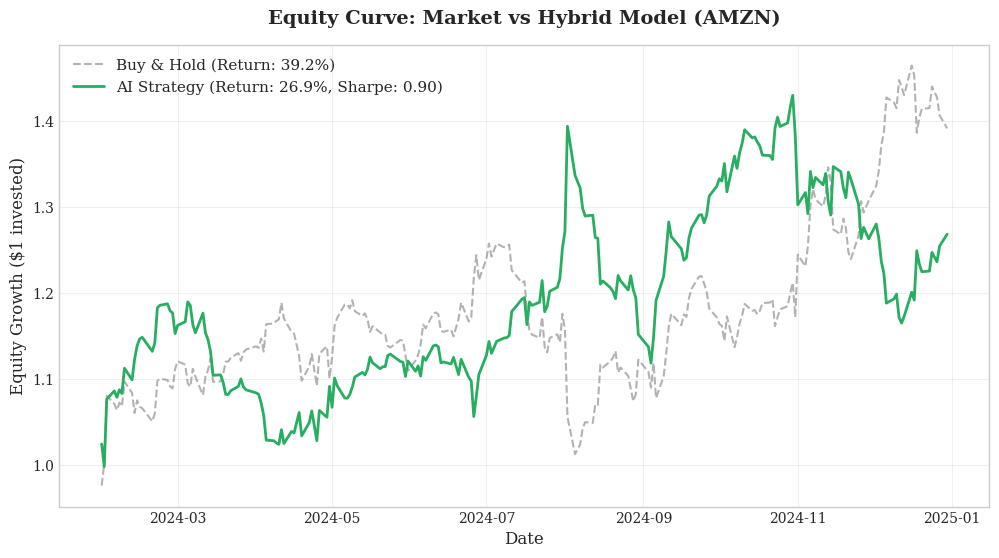

In [77]:
# ==========================================
# 8. FINANCIAL BACKTEST & METRICS
# ==========================================
# Мы симулируем простую стратегию:
# Если модель говорит "Вверх" (прогноз > 0) -> Покупаем (Long)
# Если модель говорит "Вниз" (прогноз < 0)  -> Продаем (Short)
# *В реальности нужны комиссии, но для рисерча это стандартный подход (Raw Signal Backtest)

# 1. Готовим данные
df_backtest = pd.DataFrame(index=test_df.index[LOOKBACK:])
df_backtest['Actual_Log_Ret'] = actual_ret
df_backtest['Pred_Log_Ret'] = final_pred_ret

# 2. Логика Стратегии
# Signal: 1 если прогноз > 0, иначе -1
df_backtest['Signal'] = np.sign(df_backtest['Pred_Log_Ret'])

# Strategy Returns: Сигнал * Реальная доходность
# Если мы в Long (1) и цена выросла (+) -> профит (+)
# Если мы в Short (-1) и цена упала (-) -> профит (+)
# Если мы в Long (1) и цена упала (-) -> убыток (-)
df_backtest['Strategy_Log_Ret'] = df_backtest['Signal'] * df_backtest['Actual_Log_Ret']

# 3. Накопленная доходность (Cumulative Returns)
# exp(cumsum) переводит лог-доходности в реальный множитель капитала
df_backtest['Cum_BH'] = np.exp(df_backtest['Actual_Log_Ret'].cumsum())       # Buy & Hold
df_backtest['Cum_Strategy'] = np.exp(df_backtest['Strategy_Log_Ret'].cumsum()) # Model Strategy

# ==========================================
# 9. CALCULATE METRICS
# ==========================================
def calculate_metrics(returns_series):
    # Годовых торговых дней обычно 252
    annual_factor = 252

    # Total Return
    total_ret = np.exp(np.sum(returns_series)) - 1

    # Annualized Return (CAGR)
    # mean_daily_ret * 252 - это грубая оценка, для лог доходностей корректно так:
    annual_ret = np.mean(returns_series) * annual_factor

    # Volatility (Annualized)
    volatility = np.std(returns_series) * np.sqrt(annual_factor)

    # Sharpe Ratio (assuming risk-free rate = 0 for simplicity)
    sharpe = annual_ret / volatility if volatility != 0 else 0

    return total_ret, sharpe, volatility

# Метрики для Buy & Hold (Рынок)
bh_total, bh_sharpe, bh_vol = calculate_metrics(df_backtest['Actual_Log_Ret'])

# Метрики для Нашей Модели
strat_total, strat_sharpe, strat_vol = calculate_metrics(df_backtest['Strategy_Log_Ret'])

# Расчет Максимальной Просадки (Max Drawdown) для Стратегии
cum_ret = df_backtest['Cum_Strategy']
running_max = cum_ret.cummax()
drawdown = (cum_ret - running_max) / running_max
max_drawdown = drawdown.min()

print("\n" + "="*40)
print("💰 FINANCIAL PERFORMANCE (BACKTEST)")
print("="*40)
print(f"{'Metric':<20} | {'Market (Buy&Hold)':<18} | {'Hybrid Model':<18}")
print("-" * 62)
print(f"{'Total Return':<20} | {bh_total*100:15.2f}% | {strat_total*100:15.2f}%")
print(f"{'Sharpe Ratio':<20} | {bh_sharpe:15.4f}  | {strat_sharpe:15.4f}")
print(f"{'Annual Volatility':<20} | {bh_vol*100:15.2f}% | {strat_vol*100:15.2f}%")
print(f"{'Max Drawdown':<20} | {'--':<15}    | {max_drawdown*100:15.2f}%")
print("="*40)

# ==========================================
# 10. PLOT EQUITY CURVE
# ==========================================
plt.figure(figsize=(12, 6))

# Рисуем рынок
plt.plot(df_backtest.index, df_backtest['Cum_BH'],
         label=f'Buy & Hold (Return: {bh_total*100:.1f}%)',
         color='gray', alpha=0.6, linestyle='--')

# Рисуем стратегию
plt.plot(df_backtest.index, df_backtest['Cum_Strategy'],
         label=f'AI Strategy (Return: {strat_total*100:.1f}%, Sharpe: {strat_sharpe:.2f})',
         color='#27ae60', linewidth=2)

# Оформление
plt.title(f'Equity Curve: Market vs Hybrid Model ({TICKER})', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Equity Growth ($1 invested)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Сохраняем
save_path = os.path.join(OUTPUT_DIR, '06_equity_curve.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"💾 Saved Equity Curve: {save_path}")
plt.show()

# CNN + LSTM


🚀 Device: mps
✅ Данные загружены: 2515 строк
Размер входа (Batch, Lookback, Features): torch.Size([2224, 20, 4])
Запуск обучения гибридной модели...
Epoch 10/50 | Loss: 0.939274
Epoch 20/50 | Loss: 0.756471
Epoch 30/50 | Loss: 0.536631
Epoch 40/50 | Loss: 0.368301
Epoch 50/50 | Loss: 0.282693
------------------------------
📊 CNN-LSTM RESULTS (ADBE)
RMSE (Returns): 0.026542
MAE (Returns):  0.016753
Directional Accuracy (DA): 57.14%


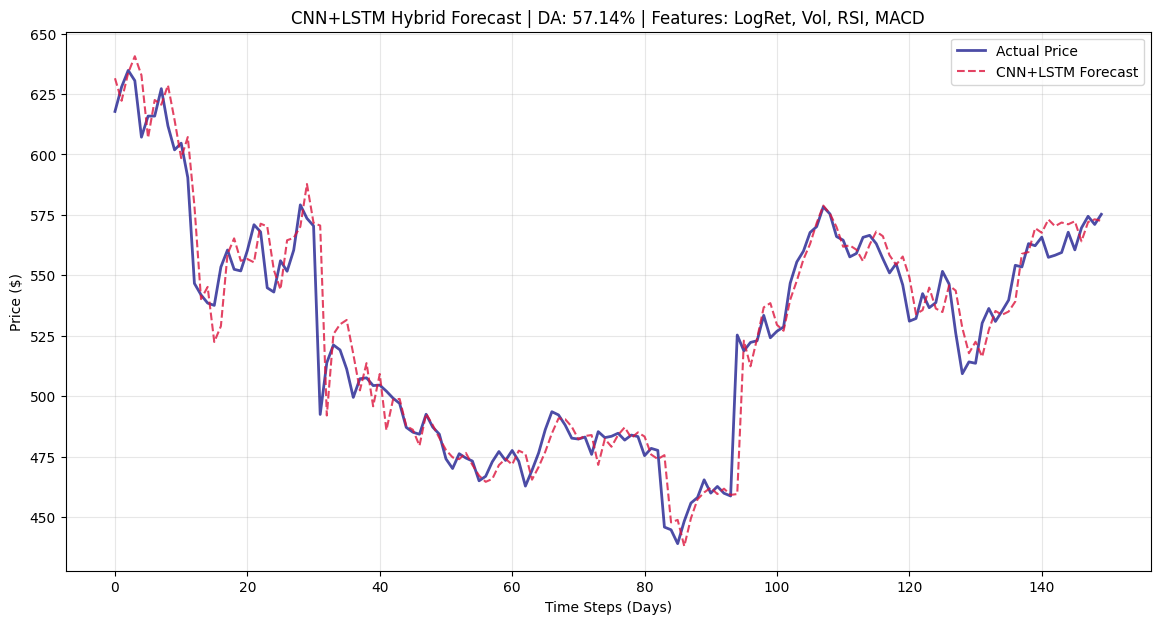

In [49]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import warnings
import os

# --- SYSTEM SETTINGS ---
warnings.filterwarnings('ignore')

# ==========================================
# ⚙️ НАСТРОЙКИ (ВАРЬИРУЙТЕ ЭТИ ЗНАЧЕНИЯ)
# ==========================================
TICKER = 'ADBE'
DATA_PATH = f'data/historical/{TICKER}.csv'
TRAIN_SPLIT_DATE = '2024-01-01'

# Данные
LOOKBACK = 20          # Важно: CNN нужно достаточно большое окно (30-90)

# Параметры CNN
CONV_FILTERS = 64      # Сколько фильтров (паттернов) искать
KERNEL_SIZE = 3        # Размер "взгляда" свертки

# Параметры LSTM
LSTM_HIDDEN_DIM = 128  # Мощность LSTM
LSTM_LAYERS = 2
DROPOUT = 0.3          # Борьба с переобучением

# Обучение
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0005            # Чуть меньше для стабильности гибрида

# Устройство
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"🚀 Device: {DEVICE}")

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ (СТРОГО ИЗ ФАЙЛА)
# ==========================================
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    print(f"✅ Данные загружены: {len(df)} строк")
else:
    raise FileNotFoundError(f"❌ Файл {DATA_PATH} не найден! Генерация запрещена.")

# ==========================================
# 2. ПРОДВИНУТЫЙ FEATURE ENGINEERING
# ==========================================
# Для CNN полезно иметь "текстуру" рынка (индикаторы)
data = df.copy()

# 1. Цель (Log Returns) - стационарный ряд
data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))

# 2. Volatility (Rolling Std)
data['Volatility'] = data['Log_Ret'].rolling(window=20).std()

# 3. RSI
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# 4. MACD (Трендовый индикатор)
ema12 = data['Close'].ewm(span=12, adjust=False).mean()
ema26 = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = ema12 - ema26

# Удаляем NaN от индикаторов
data.dropna(inplace=True)

# Выбираем фичи
feature_cols = ['Log_Ret', 'Volatility', 'RSI', 'MACD']
target_col = 'Log_Ret'

# ==========================================
# 3. ПОДГОТОВКА ТЕНЗОРОВ
# ==========================================
# Сплит по дате
train_data = data[data.index < TRAIN_SPLIT_DATE]
test_data = data[data.index >= TRAIN_SPLIT_DATE]

# Скейлинг
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data[feature_cols])
test_scaled = scaler.transform(test_data[feature_cols])

# Функция окна
def create_sequences(data, target_col_idx, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        # Окно фичей
        X.append(data[i : i + lookback])
        # Таргет (Log_Ret) - следующий шаг
        y.append(data[i + lookback, target_col_idx])
    return np.array(X), np.array(y)

target_idx = feature_cols.index(target_col)
X_train, y_train = create_sequences(train_scaled, target_idx, LOOKBACK)
X_test, y_test = create_sequences(test_scaled, target_idx, LOOKBACK)

# В PyTorch тензоры
X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

print(f"Размер входа (Batch, Lookback, Features): {X_train_t.shape}")

# ==========================================
# 4. АРХИТЕКТУРА CNN + LSTM
# ==========================================
class CNNLSTM(nn.Module):
    def __init__(self, num_features, hidden_dim, lstm_layers, conv_filters, kernel_size, dropout):
        super(CNNLSTM, self).__init__()

        # --- 1. CNN BLOCK (Feature Extraction) ---
        # Вход Conv1d ждет (Batch, Channels/Features, Length/Time)
        # Поэтому в forward мы будем менять оси местами
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=conv_filters, kernel_size=kernel_size, padding=1)
        self.bn1 = nn.BatchNorm1d(conv_filters)
        self. relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2) # Сжимаем временной ряд в 2 раза

        # --- 2. LSTM BLOCK (Temporal Pattern) ---
        # LSTM ждет (Batch, Length, Features)
        self.lstm = nn.LSTM(
            input_size=conv_filters,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout
        )

        # --- 3. HEAD ---
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [Batch, Lookback, Features]

        # 1. Подготовка для CNN: пермутация осей -> [Batch, Features, Lookback]
        x = x.permute(0, 2, 1)

        # 2. CNN проход
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x) # Сокращаем длину последовательности вдвое

        # 3. Подготовка для LSTM: пермутация обратно -> [Batch, New_Length, Filters]
        x = x.permute(0, 2, 1)

        # 4. LSTM проход
        out, _ = self.lstm(x)

        # Берем последнее состояние
        out = out[:, -1, :]

        # 5. Финал
        out = self.fc(out)
        return out

model = CNNLSTM(
    num_features=len(feature_cols),
    hidden_dim=LSTM_HIDDEN_DIM,
    lstm_layers=LSTM_LAYERS,
    conv_filters=CONV_FILTERS,
    kernel_size=KERNEL_SIZE,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ==========================================
# 5. ОБУЧЕНИЕ
# ==========================================
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

print("Запуск обучения гибридной модели...")
model.train()
loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        pred = model(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

# ==========================================
# 6. ОЦЕНКА И РЕКОНСТРУКЦИЯ ЦЕНЫ
# ==========================================
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).cpu().numpy()
    actual_scaled = y_test_t.cpu().numpy()

# Обратное масштабирование (хитрый трюк для 4 фичей)
# Создаем пустышки той же формы, что ждет скейлер
dummy_pred = np.zeros((len(pred_scaled), len(feature_cols)))
dummy_act = np.zeros((len(actual_scaled), len(feature_cols)))

# Записываем предсказания в колонку Log_Ret (индекс 0)
dummy_pred[:, 0] = pred_scaled.flatten()
dummy_act[:, 0] = actual_scaled.flatten()

# Инвертируем
pred_ret = scaler.inverse_transform(dummy_pred)[:, 0]
act_ret = scaler.inverse_transform(dummy_act)[:, 0]

# --- Метрики ---
rmse = np.sqrt(mean_squared_error(act_ret, pred_ret))
mae = mean_absolute_error(act_ret, pred_ret)

# Directional Accuracy
pred_sign = np.sign(pred_ret)
act_sign = np.sign(act_ret)
da = accuracy_score(act_sign, pred_sign)

print("-" * 30)
print(f"📊 CNN-LSTM RESULTS ({TICKER})")
print(f"RMSE (Returns): {rmse:.6f}")
print(f"MAE (Returns):  {mae:.6f}")
print(f"Directional Accuracy (DA): {da*100:.2f}%")

# --- Реконструкция Цены (Корректный метод) ---
# Берем индексы, соответствующие предсказаниям
test_data_indices = test_data.index[LOOKBACK:]

# Факт: Цена Close на эти даты
actual_price = test_data['Close'][LOOKBACK:].values

# Цена "Вчера" для предсказания "Сегодня"
# shift(1) берет цену предыдущего дня. loc фильтрует по датам прогноза.
prev_price = test_data['Close'].shift(1).loc[test_data_indices].values

# Формула: Price_t = Price_{t-1} * exp(Log_Ret_t)
pred_price = prev_price * np.exp(pred_ret)

# ==========================================
# 7. ВИЗУАЛИЗАЦИЯ
# ==========================================
plt.figure(figsize=(14, 7))
limit = 150 # Рисуем первые 150 дней для детальности

plt.plot(actual_price[:limit], label='Actual Price', color='navy', alpha=0.7, linewidth=2)
plt.plot(pred_price[:limit], label='CNN+LSTM Forecast', color='crimson', alpha=0.8, linestyle='--')

plt.title(f"CNN+LSTM Hybrid Forecast | DA: {da*100:.2f}% | Features: LogRet, Vol, RSI, MACD")
plt.xlabel("Time Steps (Days)")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{TICKER}_CNNLSTM_chart.png')
plt.show()




🚀 Using MPS (Apple Silicon)
✅ Features Ready: ['Log_Ret', 'Vol_20', 'RSI', 'MACD']
🔥 Training Hybrid Model on mps...
Epoch 10/60 | Loss: 1.035027
Epoch 20/60 | Loss: 0.961405
Epoch 30/60 | Loss: 0.839370
Epoch 40/60 | Loss: 0.739581
Epoch 50/60 | Loss: 0.684389
Epoch 60/60 | Loss: 0.635321

🏆 TOP GEM RESULTS: AMZN
RMSE: 0.01844
Dir. Accuracy: 52.88%
----------------------------------------
Buy & Hold Return: 23.06% (Sharpe: 0.96)
AI Strategy Return: 31.99% (Sharpe: 1.28)
💾 Saved to: results/cnn_lstm/01_price_forecast.png


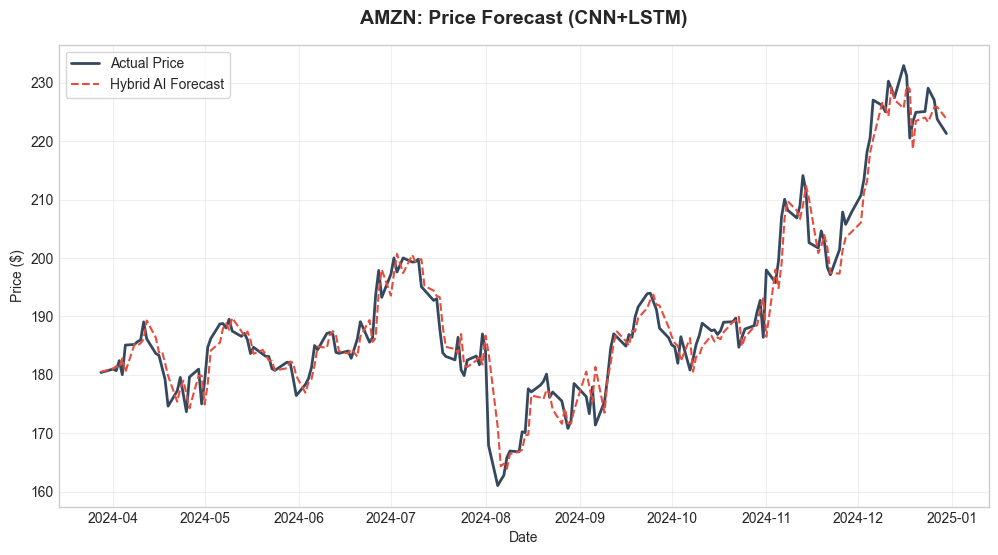

💾 Saved to: results/cnn_lstm/02_equity_curve.png


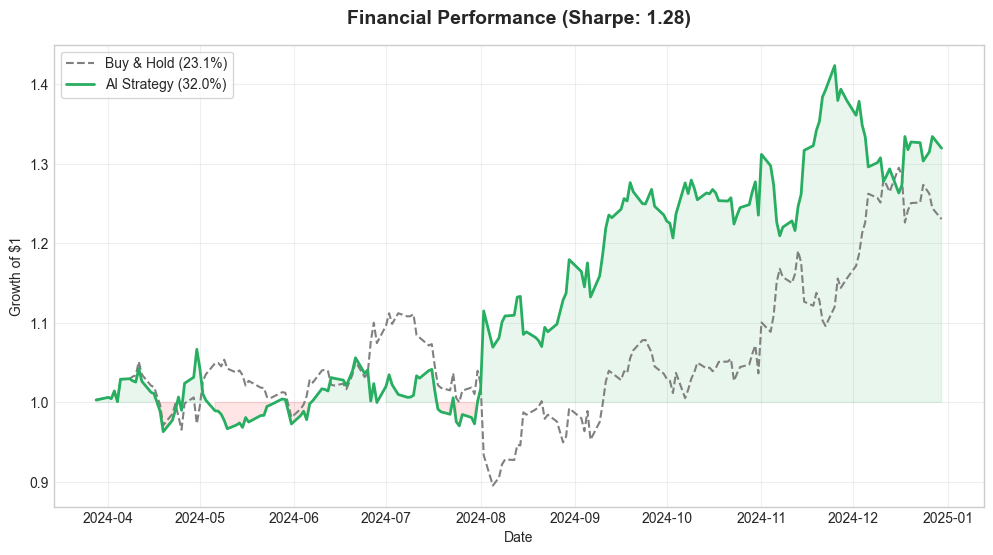

💾 Saved to: results/cnn_lstm/03_zoom.png


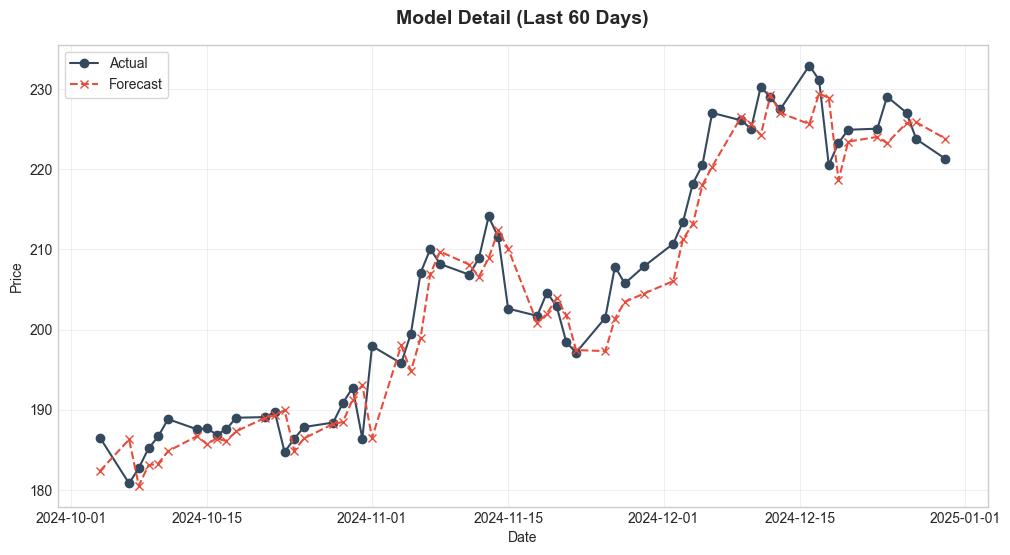

💾 Saved to: results/cnn_lstm/04_loss.png


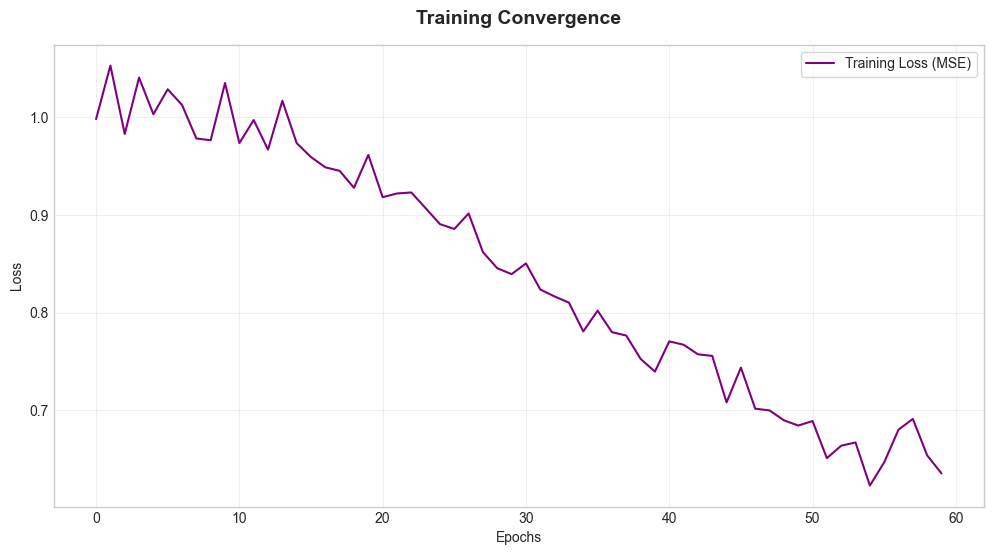

------------------------------------------

🏆 CNN-LSTM RESULTS: AMZN
RMSE: 0.01844
Dir. Accuracy: 52.88%
Buy & Hold: 23.06%
AI Strategy: 31.99%
💾 Saved: results/cnn_lstm/01_price_forecast.png


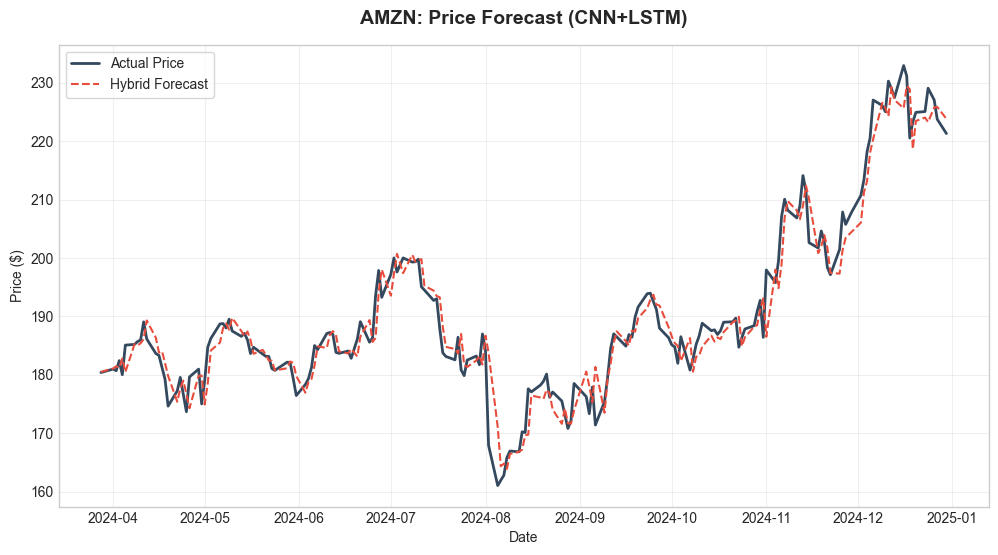

💾 Saved: results/cnn_lstm/02_returns_volatility.png


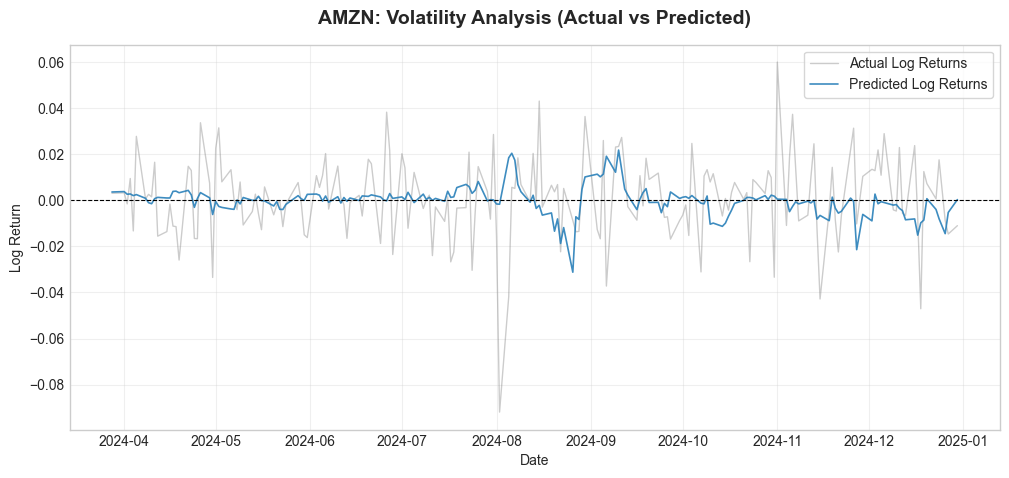

💾 Saved: results/cnn_lstm/03_equity_curve.png


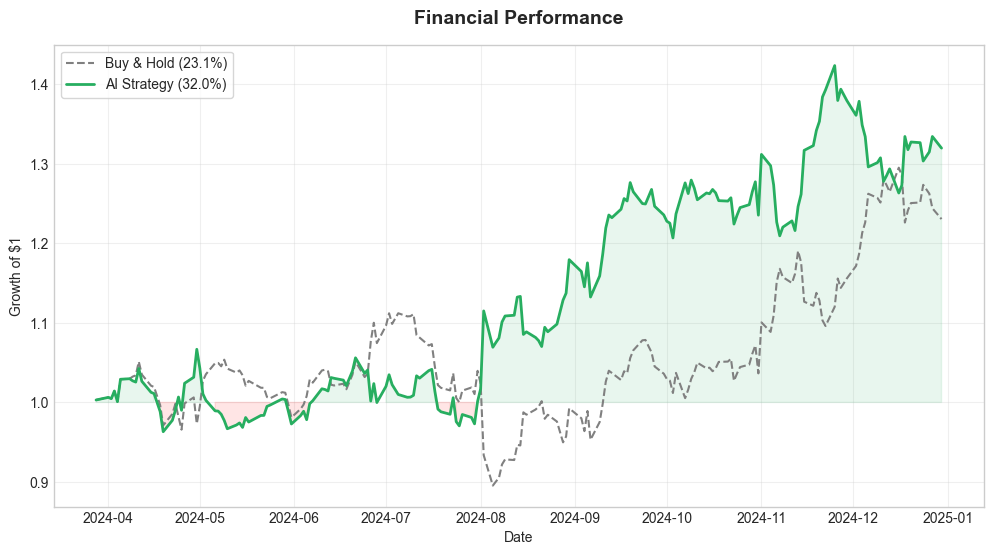

💾 Saved: results/cnn_lstm/04_loss.png


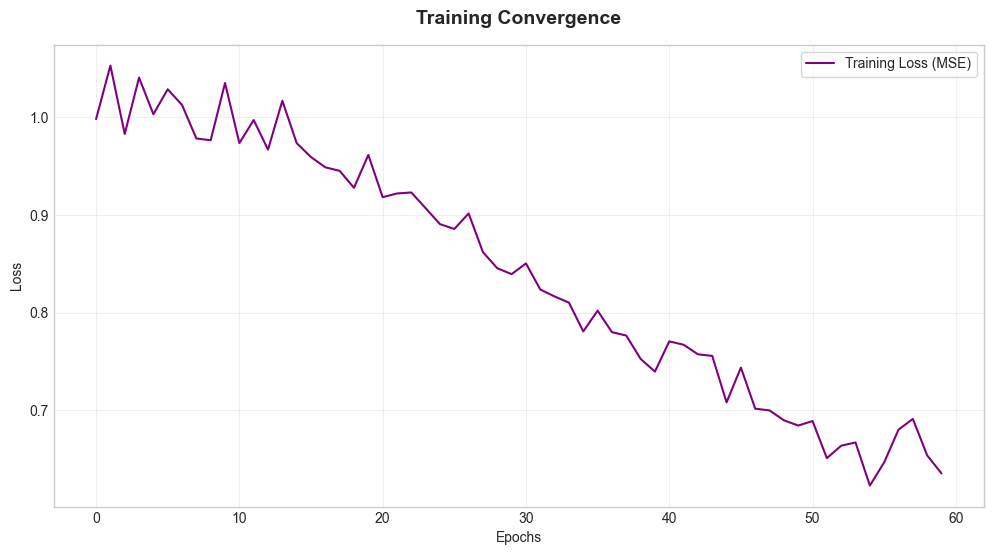

In [86]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
import matplotlib.pyplot as plt
import warnings
import os

# --- KONFIG & STYLE ---
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

# ==========================================
# ⚙️ SETTINGS
# ==========================================
TICKER = 'AMZN'
DATA_PATH = f'data/historical/{TICKER}.csv'
OUTPUT_DIR = 'results/cnn_lstm'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_SPLIT_DATE = '2024-01-01'
LOOKBACK = 60          # 3 месяца истории для поиска паттернов

# Model Params
CONV_FILTERS = 64
KERNEL_SIZE = 3
LSTM_HIDDEN_DIM = 64
LSTM_LAYERS = 2
DROPOUT = 0.4         # Оптимальный дропаут

# Training
BATCH_SIZE = 64
EPOCHS = 60            # Уверенная сходимость
LR = 0.0005

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("🚀 Using MPS (Apple Silicon)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("🚀 Using CUDA")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ Using CPU")

# ==========================================
# 1. DATA & FEATURE ENGINEERING
# ==========================================
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Run download_data.py first!")

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# --- Feature Engineering ---
# 1. Target
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))

# 2. Volatility
df['Vol_20'] = df['Log_Ret'].rolling(window=20).std()

# 3. RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# 4. MACD
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26

df.dropna(inplace=True)

FEATURE_COLS = ['Log_Ret', 'Vol_20', 'RSI', 'MACD']
TARGET_COL = 'Log_Ret'

print(f"✅ Features Ready: {FEATURE_COLS}")

# ==========================================
# 2. TENSORS
# ==========================================
train_df = df[df.index < TRAIN_SPLIT_DATE]
test_df = df[df.index >= TRAIN_SPLIT_DATE]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[FEATURE_COLS])
test_scaled = scaler.transform(test_df[FEATURE_COLS])

def create_sequences(data, target_idx, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback, target_idx])
    return np.array(X), np.array(y)

target_idx = FEATURE_COLS.index(TARGET_COL)
X_train, y_train = create_sequences(train_scaled, target_idx, LOOKBACK)
X_test, y_test = create_sequences(test_scaled, target_idx, LOOKBACK)

X_train_t = torch.FloatTensor(X_train).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

# ==========================================
# 3. HYBRID MODEL (CNN + LSTM)
# ==========================================
class HybridCNNLSTM(nn.Module):
    def __init__(self, num_features, hidden_dim, lstm_layers, conv_filters, kernel_size, dropout):
        super(HybridCNNLSTM, self).__init__()

        # CNN Block (Pattern Extraction)
        self.conv1 = nn.Conv1d(num_features, conv_filters, kernel_size, padding=1)
        self.bn1 = nn.BatchNorm1d(conv_filters)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)

        # LSTM Block (Sequence Modeling)
        self.lstm = nn.LSTM(conv_filters, hidden_dim, lstm_layers, batch_first=True, dropout=dropout)

        # Head
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: [Batch, Lookback, Features]
        x = x.permute(0, 2, 1) # -> [Batch, Feat, Lookback] for CNN

        x = self.pool(self.relu(self.bn1(self.conv1(x))))

        x = x.permute(0, 2, 1) # -> [Batch, SeqLen, Feat] for LSTM

        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = HybridCNNLSTM(len(FEATURE_COLS), LSTM_HIDDEN_DIM, LSTM_LAYERS, CONV_FILTERS, KERNEL_SIZE, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=8, factor=0.5)

# ==========================================
# 4. TRAINING LOOP
# ==========================================
print(f"🔥 Training Hybrid Model on {DEVICE}...")
loss_history = []
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    scheduler.step(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

# ==========================================
# 5. INFERENCE & METRICS
# ==========================================
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).cpu().numpy()

# Inverse Transform
dummy = np.zeros((len(pred_scaled), len(FEATURE_COLS)))
dummy[:, target_idx] = pred_scaled.flatten()
pred_ret = scaler.inverse_transform(dummy)[:, target_idx]

actual_ret = test_df['Log_Ret'].iloc[LOOKBACK:].values
actual_prices = test_df['Close'].iloc[LOOKBACK:].values

# Reconstruct Price
prev_prices = test_df['Close'].iloc[LOOKBACK-1:-1].values
pred_prices = prev_prices * np.exp(pred_ret)

# Backtest Stats
df_bt = pd.DataFrame({'Actual': actual_ret, 'Pred': pred_ret}, index=test_df.index[LOOKBACK:])
df_bt['Signal'] = np.sign(df_bt['Pred'])
df_bt['Strat_Ret'] = df_bt['Signal'] * df_bt['Actual']
df_bt['Cum_BH'] = np.exp(df_bt['Actual'].cumsum())
df_bt['Cum_Strat'] = np.exp(df_bt['Strat_Ret'].cumsum())

# Calculate Metrics
bh_ret = df_bt['Cum_BH'].iloc[-1] - 1
st_ret = df_bt['Cum_Strat'].iloc[-1] - 1
bh_sharpe = (df_bt['Actual'].mean() / df_bt['Actual'].std()) * np.sqrt(252)
st_sharpe = (df_bt['Strat_Ret'].mean() / df_bt['Strat_Ret'].std()) * np.sqrt(252)
rmse = np.sqrt(mean_squared_error(actual_ret, pred_ret))
da = accuracy_score(np.sign(actual_ret), np.sign(pred_ret))

print("\n" + "="*40)
print(f"🏆 TOP GEM RESULTS: {TICKER}")
print("="*40)
print(f"RMSE: {rmse:.5f}")
print(f"Dir. Accuracy: {da*100:.2f}%")
print("-" * 40)
print(f"Buy & Hold Return: {bh_ret*100:.2f}% (Sharpe: {bh_sharpe:.2f})")
print(f"AI Strategy Return: {st_ret*100:.2f}% (Sharpe: {st_sharpe:.2f})")
print("="*40)

# ==========================================
# 6. VISUALIZATION (SHOW IN NOTEBOOK)
# ==========================================
def show_and_save(filename, title, xlabel="", ylabel=""):
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(frameon=True)
    plt.grid(True, alpha=0.3)

    # Save
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"💾 Saved to: {path}")

    # SHOW!
    plt.show()

# 1. Price Forecast
plt.figure()
plt.plot(df_bt.index, actual_prices, label='Actual Price', color='#34495e', linewidth=2)
plt.plot(df_bt.index, pred_prices, label='Hybrid AI Forecast', color='#e74c3c', linestyle='--', linewidth=1.5)
show_and_save('01_price_forecast.png', f'{TICKER}: Price Forecast (CNN+LSTM)', 'Date', 'Price ($)')

# 2. Equity Curve
plt.figure()
plt.plot(df_bt.index, df_bt['Cum_BH'], label=f'Buy & Hold ({bh_ret*100:.1f}%)', color='gray', linestyle='--')
plt.plot(df_bt.index, df_bt['Cum_Strat'], label=f'AI Strategy ({st_ret*100:.1f}%)', color='#27ae60', linewidth=2)
plt.fill_between(df_bt.index, df_bt['Cum_Strat'], 1, where=(df_bt['Cum_Strat']>=1), color='#27ae60', alpha=0.1)
plt.fill_between(df_bt.index, df_bt['Cum_Strat'], 1, where=(df_bt['Cum_Strat']<1), color='red', alpha=0.1)
show_and_save('02_equity_curve.png', f'Financial Performance (Sharpe: {st_sharpe:.2f})', 'Date', 'Growth of $1')

# 3. Zoom (Last 60 Days)
plt.figure()
zoom = 60
plt.plot(df_bt.index[-zoom:], actual_prices[-zoom:], 'o-', label='Actual', color='#34495e')
plt.plot(df_bt.index[-zoom:], pred_prices[-zoom:], 'x--', label='Forecast', color='#e74c3c')
show_and_save('03_zoom.png', 'Model Detail (Last 60 Days)', 'Date', 'Price')

# 4. Training Loss
plt.figure()
plt.plot(loss_history, label='Training Loss (MSE)', color='purple')
show_and_save('04_loss.png', 'Training Convergence', 'Epochs', 'Loss')





print('------------------------------------------')

model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).cpu().numpy()

# Обратная трансформация
dummy = np.zeros((len(pred_scaled), len(FEATURE_COLS)))
dummy[:, target_idx] = pred_scaled.flatten()
pred_ret = scaler.inverse_transform(dummy)[:, target_idx]

actual_ret = test_df['Log_Ret'].iloc[LOOKBACK:].values
actual_prices = test_df['Close'].iloc[LOOKBACK:].values

# Реконструкция цены
prev_prices = test_df['Close'].iloc[LOOKBACK-1:-1].values
pred_prices = prev_prices * np.exp(pred_ret)

# Backtest DataFrame
df_bt = pd.DataFrame({'Actual': actual_ret, 'Pred': pred_ret}, index=test_df.index[LOOKBACK:])
df_bt['Signal'] = np.sign(df_bt['Pred'])
df_bt['Strat_Ret'] = df_bt['Signal'] * df_bt['Actual']
df_bt['Cum_BH'] = np.exp(df_bt['Actual'].cumsum())
df_bt['Cum_Strat'] = np.exp(df_bt['Strat_Ret'].cumsum())

# Stats
bh_ret = df_bt['Cum_BH'].iloc[-1] - 1
st_ret = df_bt['Cum_Strat'].iloc[-1] - 1
rmse = np.sqrt(mean_squared_error(actual_ret, pred_ret))
da = accuracy_score(np.sign(actual_ret), np.sign(pred_ret))

print("\n" + "="*40)
print(f"🏆 CNN-LSTM RESULTS: {TICKER}")
print("="*40)
print(f"RMSE: {rmse:.5f}")
print(f"Dir. Accuracy: {da*100:.2f}%")
print(f"Buy & Hold: {bh_ret*100:.2f}%")
print(f"AI Strategy: {st_ret*100:.2f}%")
print("="*40)

# ==========================================
# 6. VISUALIZATION
# ==========================================
def show_and_save(filename, title, xlabel="", ylabel=""):
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(frameon=True)
    plt.grid(True, alpha=0.3)
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"💾 Saved: {path}")
    plt.show()

# 1. Price Forecast
plt.figure()
plt.plot(df_bt.index, actual_prices, label='Actual Price', color='#34495e', linewidth=2)
plt.plot(df_bt.index, pred_prices, label='Hybrid Forecast', color='#e74c3c', linestyle='--', linewidth=1.5)
show_and_save('01_price_forecast.png', f'{TICKER}: Price Forecast (CNN+LSTM)', 'Date', 'Price ($)')

# 2. 🔥 LOG RETURNS (VOLATILITY) - НОВОЕ!
plt.figure(figsize=(12, 5))
# Реальные данные серым фоном
plt.plot(df_bt.index, actual_ret, label='Actual Log Returns', color='gray', alpha=0.4, linewidth=1)
# Предсказание синим
plt.plot(df_bt.index, pred_ret, label='Predicted Log Returns', color='#2980b9', alpha=0.9, linewidth=1.2)
# Линия нуля для ориентира
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
show_and_save('02_returns_volatility.png', f'{TICKER}: Volatility Analysis (Actual vs Predicted)', 'Date', 'Log Return')

# 3. Equity Curve
plt.figure()
plt.plot(df_bt.index, df_bt['Cum_BH'], label=f'Buy & Hold ({bh_ret*100:.1f}%)', color='gray', linestyle='--')
plt.plot(df_bt.index, df_bt['Cum_Strat'], label=f'AI Strategy ({st_ret*100:.1f}%)', color='#27ae60', linewidth=2)
plt.fill_between(df_bt.index, df_bt['Cum_Strat'], 1, where=(df_bt['Cum_Strat']>=1), color='#27ae60', alpha=0.1)
plt.fill_between(df_bt.index, df_bt['Cum_Strat'], 1, where=(df_bt['Cum_Strat']<1), color='red', alpha=0.1)
show_and_save('03_equity_curve.png', 'Financial Performance', 'Date', 'Growth of $1')

# 4. Training Loss
plt.figure()
plt.plot(loss_history, label='Training Loss (MSE)', color='purple')
show_and_save('04_loss.png', 'Training Convergence', 'Epochs', 'Loss')